# Study one zstar ouptut

This notebook contains analysis and figures intended for use in the first part of a study on numerical mixing: *Numerical Mixing in Finite Volume Ocean Models Part 1: Derivation and implementation of a diagnostic formula*.
This study will look at an implementation of the numerical mixing diagnostic only in the zstar case at 0.25 degree resolution.

The data used to generate the `*.jld2` analysis files is over 20 years (model years 60-80).

In [27]:
tub_output_dir = "/g/data/e14/jb2381/anu-tub/outputs"
if pwd() != tub_output_dir 
    cd(tub_output_dir)
end
include("plotting.jl")

  Activating project at `/g/data/e14/jb2381/anu-tub/outputs`
[ Info: Plotting and analysis environment setup!
┌ Info: Experiments in the catalogue are: ["zstar-weaker-KD", "alt-hycom-weaker-KD", "alt-hycom", "hycom1-weaker-KD", "zstar", "adapt", "adapt-weaker-KD", "hycom1"]
│       Available data is:
│       - monthly
│       - monthlyz
│       - monthlyrho2
│       - static
└       - vertical coordinate
┌ Info: Analysis files available:
│       - vgrids: /g/data/e14/jb2381/anu-tub/outputs/vertical_grids.jld2
│       - model_states: /g/data/e14/jb2381/anu-tub/outputs/model_states.jld2
└       - variance_production_025: /g/data/e14/jb2381/anu-tub/outputs/variance_production_025.jld2


In [2]:
θcrange = (-2, 30)
dθcrange = (-0.2, 0.2)
ψbcrange = range(-30, 70, 30)
ucrange = (-0.05, 0.05)
ψocrange = range(-9, 9, 20)

vertical_coord = "zstar"

f = jldopen(vgrids)
htransect = f[vertical_coord]["h_transect"]
close(f)

f = jldopen(model_states)
mo = f[vertical_coord] # model output for zstar
close(f)

f = jldopen(vp025)
vp = f[vertical_coord]
close(f)

@info "$(vertical_coord) variance production loaded"

[ Info: zstar variance production loaded


## Model state

Figure containing important model fields to show what ANU-TUB looks like.

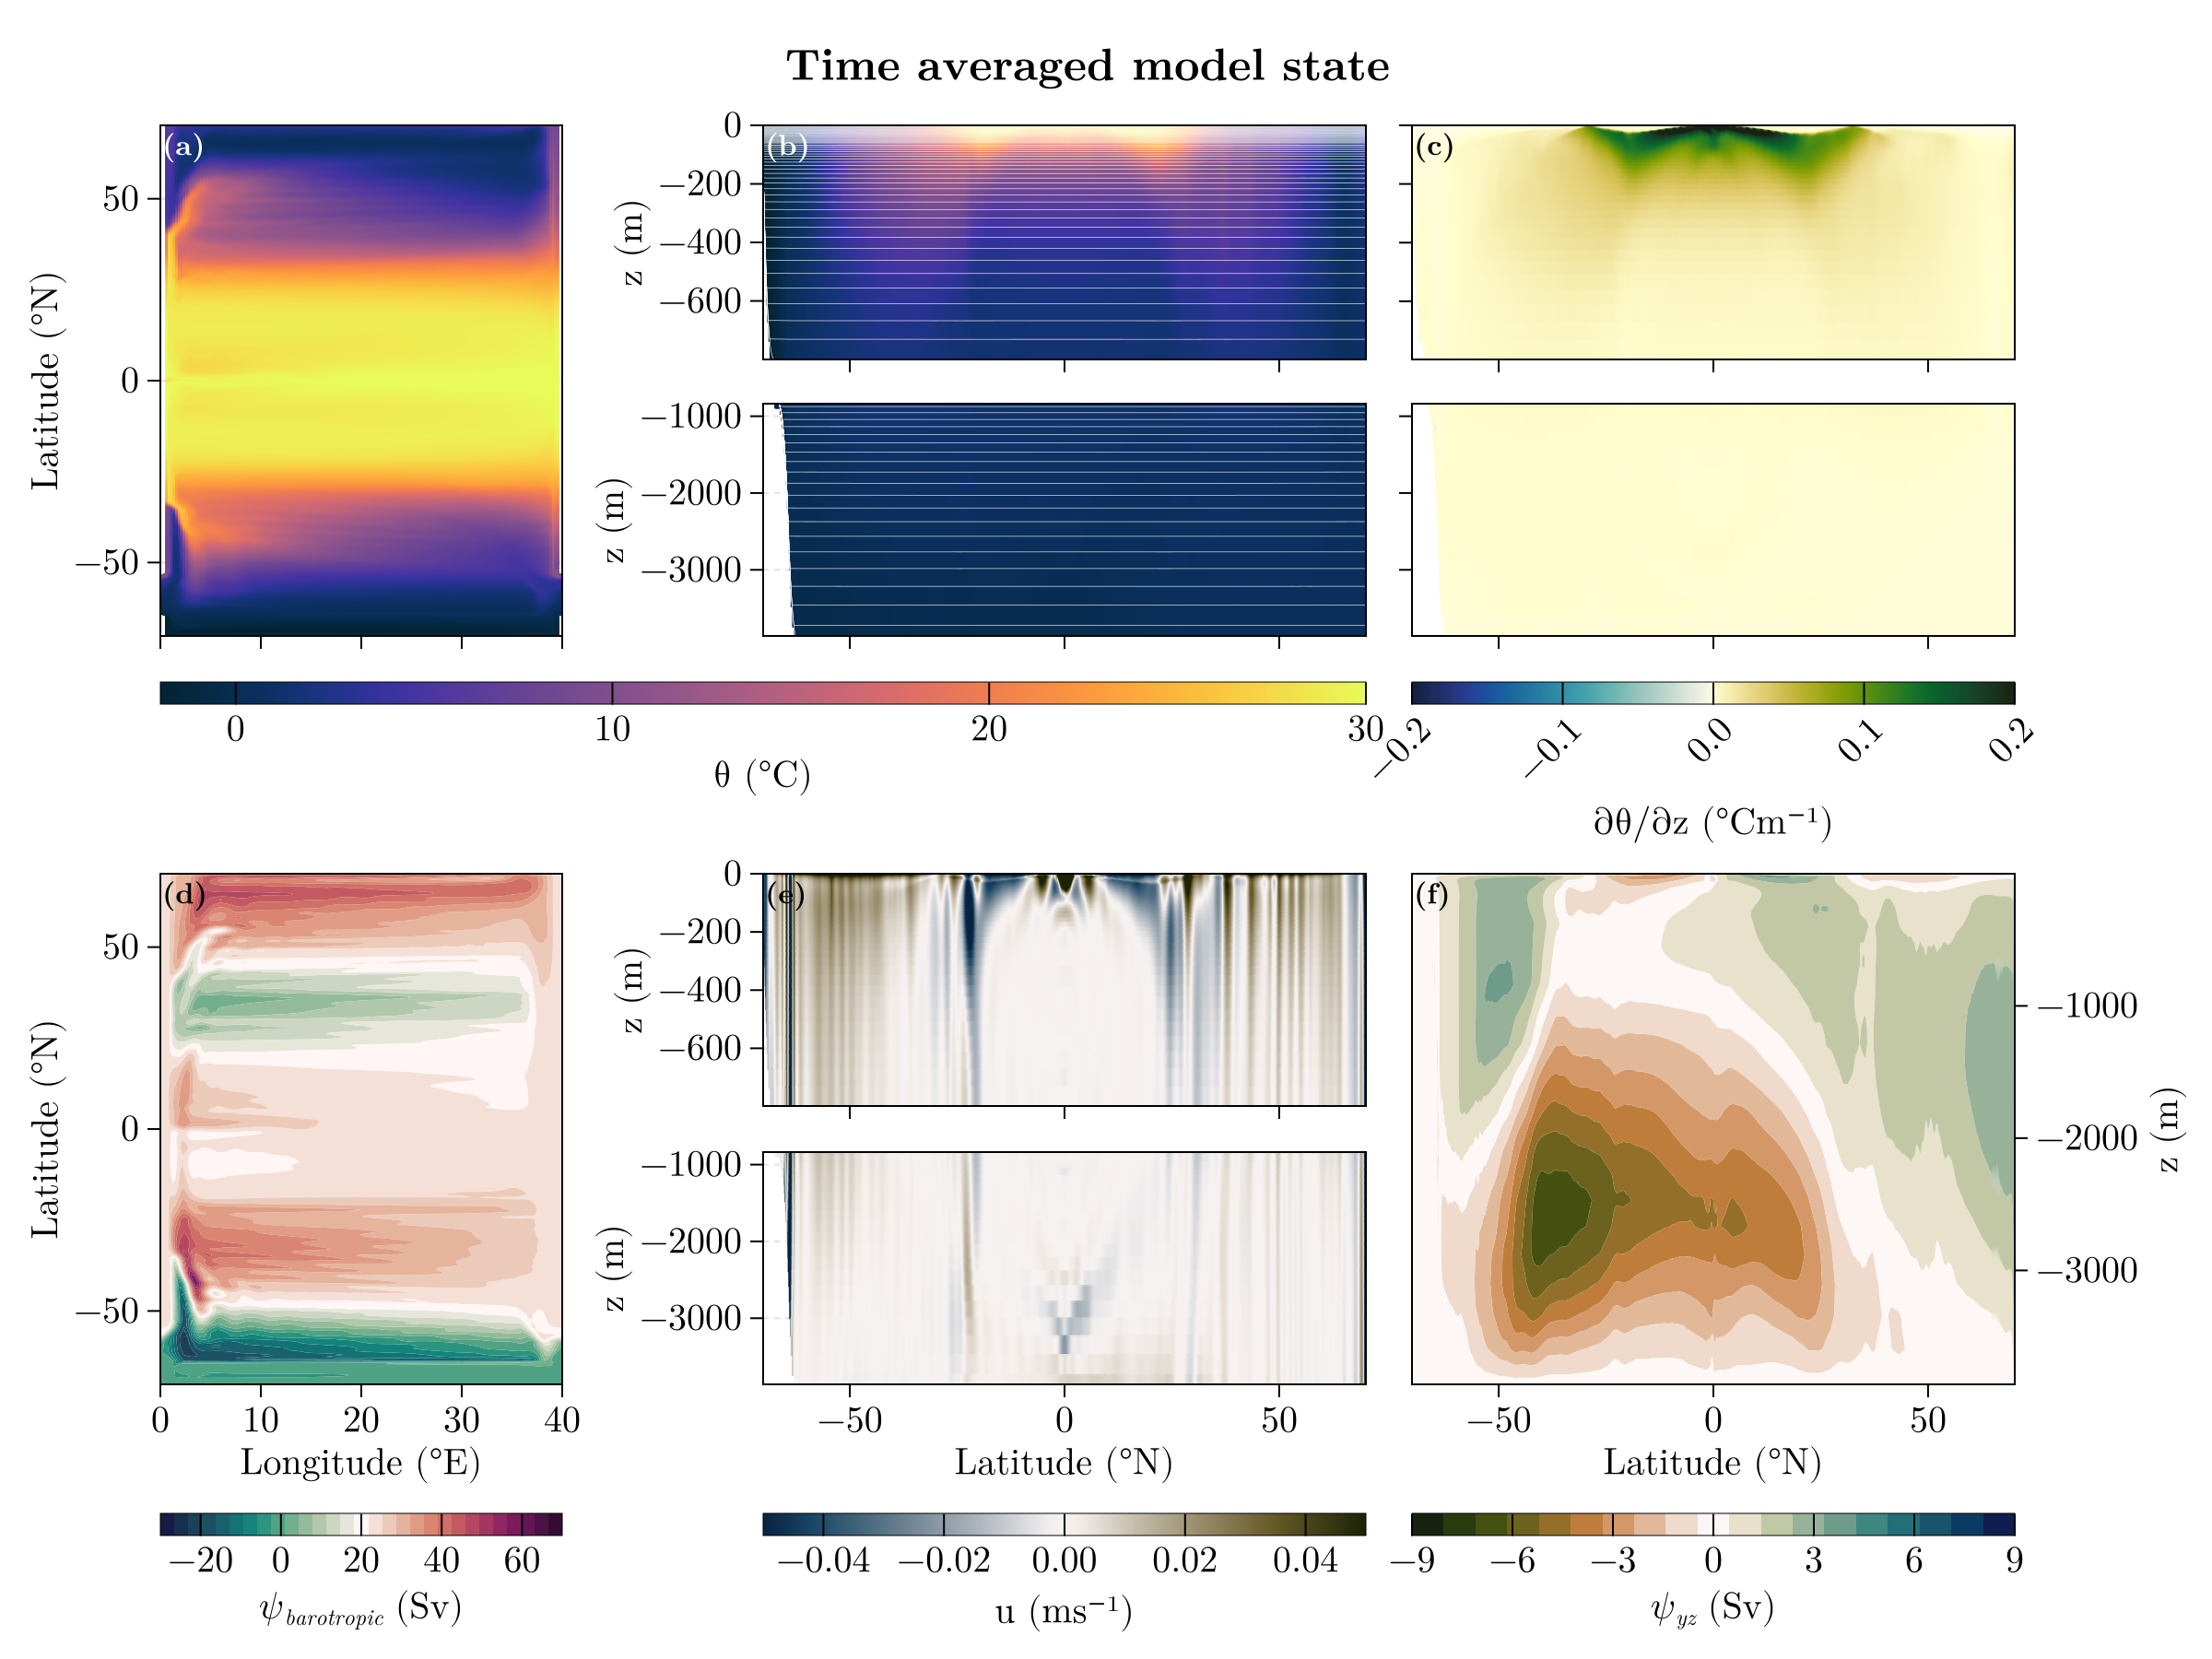

In [3]:
panel_labels = "(" .* string.('a':'r') .* ")"
fig = Figure(size = (1200, 900))

ax_sst = Axis(fig[1:2, 1], xlabel = "Longitude (°E)", ylabel = "Latitude (°N)")
hidexdecorations!(ax_sst, ticks = false)
hm = heatmap!(ax_sst, mo["crs"].lonh, mo["crs"].lath, mo["sst"], colorrange = θcrange, colormap = :thermal)
text!(ax_sst, 0, 1,
          text = panel_labels[1],
          font = :bold,
          color = :white,
          align = (:left, :top),
          offset = (1, 2),
          space = :relative,
          fontsize = 16)

top = 1:55
bot = top[end]+1:75

axtop = Axis(fig[1, 2], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axtop, mo["crs"].lath, mo["diagnostic_zl"][top], mo["tzm"][:, top], colorrange = θcrange, colormap = :thermal)
for i ∈ top
    lines!(axtop, mo["crs"].lath, -htransect[:, i], color = :white, linewidth = 0.3)
end
axbot = Axis(fig[2, 2], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot, mo["crs"].lath, mo["diagnostic_zl"][bot], mo["tzm"][:, bot], colorrange = θcrange, colormap = :thermal)
for i ∈ bot
    lines!(axbot, mo["crs"].lath, -htransect[:, i], color = :white, linewidth = 0.3)
end
ylims!(axbot, mo["diagnostic_zl"][bot[end]], mo["diagnostic_zl"][bot[1]])
Colorbar(fig[3, 1:2], hm, vertical = false, flipaxis = false, label = "θ (°C)")
text!(axtop, 0, 1,
          text = panel_labels[2],
          font = :bold,
          color = :white,
          align = (:left, :top),
          offset = (1, 2),
          space = :relative,
          fontsize = 16)

hidexdecorations!(axtop, ticks = false)
hidexdecorations!(axbot, ticks = false)

axtop = Axis(fig[1, 3], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axtop, mo["crs"].lath, mo["diagnostic_zl"][top], mo["dθdz"][:, top]; colorrange = dθcrange, colormap = :delta)
axbot = Axis(fig[2, 3], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot, mo["crs"].lath, mo["diagnostic_zl"][bot], mo["dθdz"][:, bot[1:end-1]]; colorrange = dθcrange, colormap = :delta)
ylims!(axbot, mo["diagnostic_zl"][bot[end]], mo["diagnostic_zl"][bot[1]])
Colorbar(fig[3, 3], hm, vertical = false, flipaxis = false, label = "∂θ/∂z (°Cm⁻¹)", ticklabelrotation = π/4)
text!(axtop, 0, 1,
          text = panel_labels[3],
          font = :bold,
          # color = :white,
          align = (:left, :top),
          offset = (1, 2),
          space = :relative,
          fontsize = 16)

hidexdecorations!(axtop, ticks = false)
hidexdecorations!(axbot, ticks = false)
hideydecorations!(axtop, ticks = false)
hideydecorations!(axbot, ticks = false)

ax_ψb = Axis(fig[4:5, 1], xlabel = "Longitude (°E)", ylabel = "Latitude (°N)")
xlims!(ax_ψb, mo["crs"].lonq[1], mo["crs"].lonq[end])
ylims!(ax_ψb, mo["crs"].lath[1], mo["crs"].lath[end])
cf = contourf!(ax_ψb, mo["crs"].lonq, mo["crs"].lath, mo["ψb"][:, :], colormap = :curl, levels = ψbcrange)
Colorbar(fig[6, 1], cf, vertical = false, flipaxis = false, label = L"$\psi_{barotropic}$ (Sv)")
text!(ax_ψb, 0, 1,
          text = panel_labels[4],
          font = :bold,
          # color = :white,
          align = (:left, :top),
          offset = (1, 2),
          space = :relative,
          fontsize = 16)

linkxaxes!(ax_sst, ax_ψb)

axtop = Axis(fig[4, 2], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axtop, mo["crs"].lath, mo["diagnostic_zl"][top], mo["uzm"][:, top]; colorrange = ucrange, colormap = :diff)
axbot = Axis(fig[5, 2], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot, mo["crs"].lath, mo["diagnostic_zl"][bot], mo["uzm"][:, bot]; colorrange = ucrange, colormap = :diff)
ylims!(axbot, mo["diagnostic_zl"][bot[end]], mo["diagnostic_zl"][bot[1]])
Colorbar(fig[6, 2], hm, vertical = false, flipaxis = false, label = "u (ms⁻¹)")
text!(axtop, 0, 1,
          text = panel_labels[5],
          font = :bold,
          # color = :white,
          align = (:left, :top),
          offset = (1, 2),
          space = :relative,
          fontsize = 16)

hidexdecorations!(axtop, ticks = false)

ax_ψo = Axis(fig[4:5, 3], xlabel = "Latitude (°N)", ylabel = "z (m)",
             yaxisposition = :right)
cf = contourf!(ax_ψo, mo["crs"].latq, -mo["zoverturning"]["layer"], mo["zoverturning"]["ψo"] , colormap = :tarn, levels = ψocrange)
Colorbar(fig[6, 3], cf, vertical = false, flipaxis = false, label = L"$\psi_{yz}$ (Sv)")
xlims!(ax_ψo, mo["crs"].latq[1], mo["crs"].latq[end])
ylims!(ax_ψo, mo["diagnostic_zl"][end], mo["diagnostic_zl"][1])
text!(ax_ψo, 0, 1,
          text = panel_labels[6],
          font = :bold,
          # color = :white,
          align = (:left, :top),
          offset = (1, 2),
          space = :relative,
          fontsize = 16)

colsize!(fig.layout, 1, Relative(1/4))

Label(fig[0, :], "Time averaged model state", fontsize = 24, font = :bold)


fig

In [14]:
save("FiguresPaper1/zstar_20yr_model_state_wgrid_xzcbar.png", fig)

## Variance production

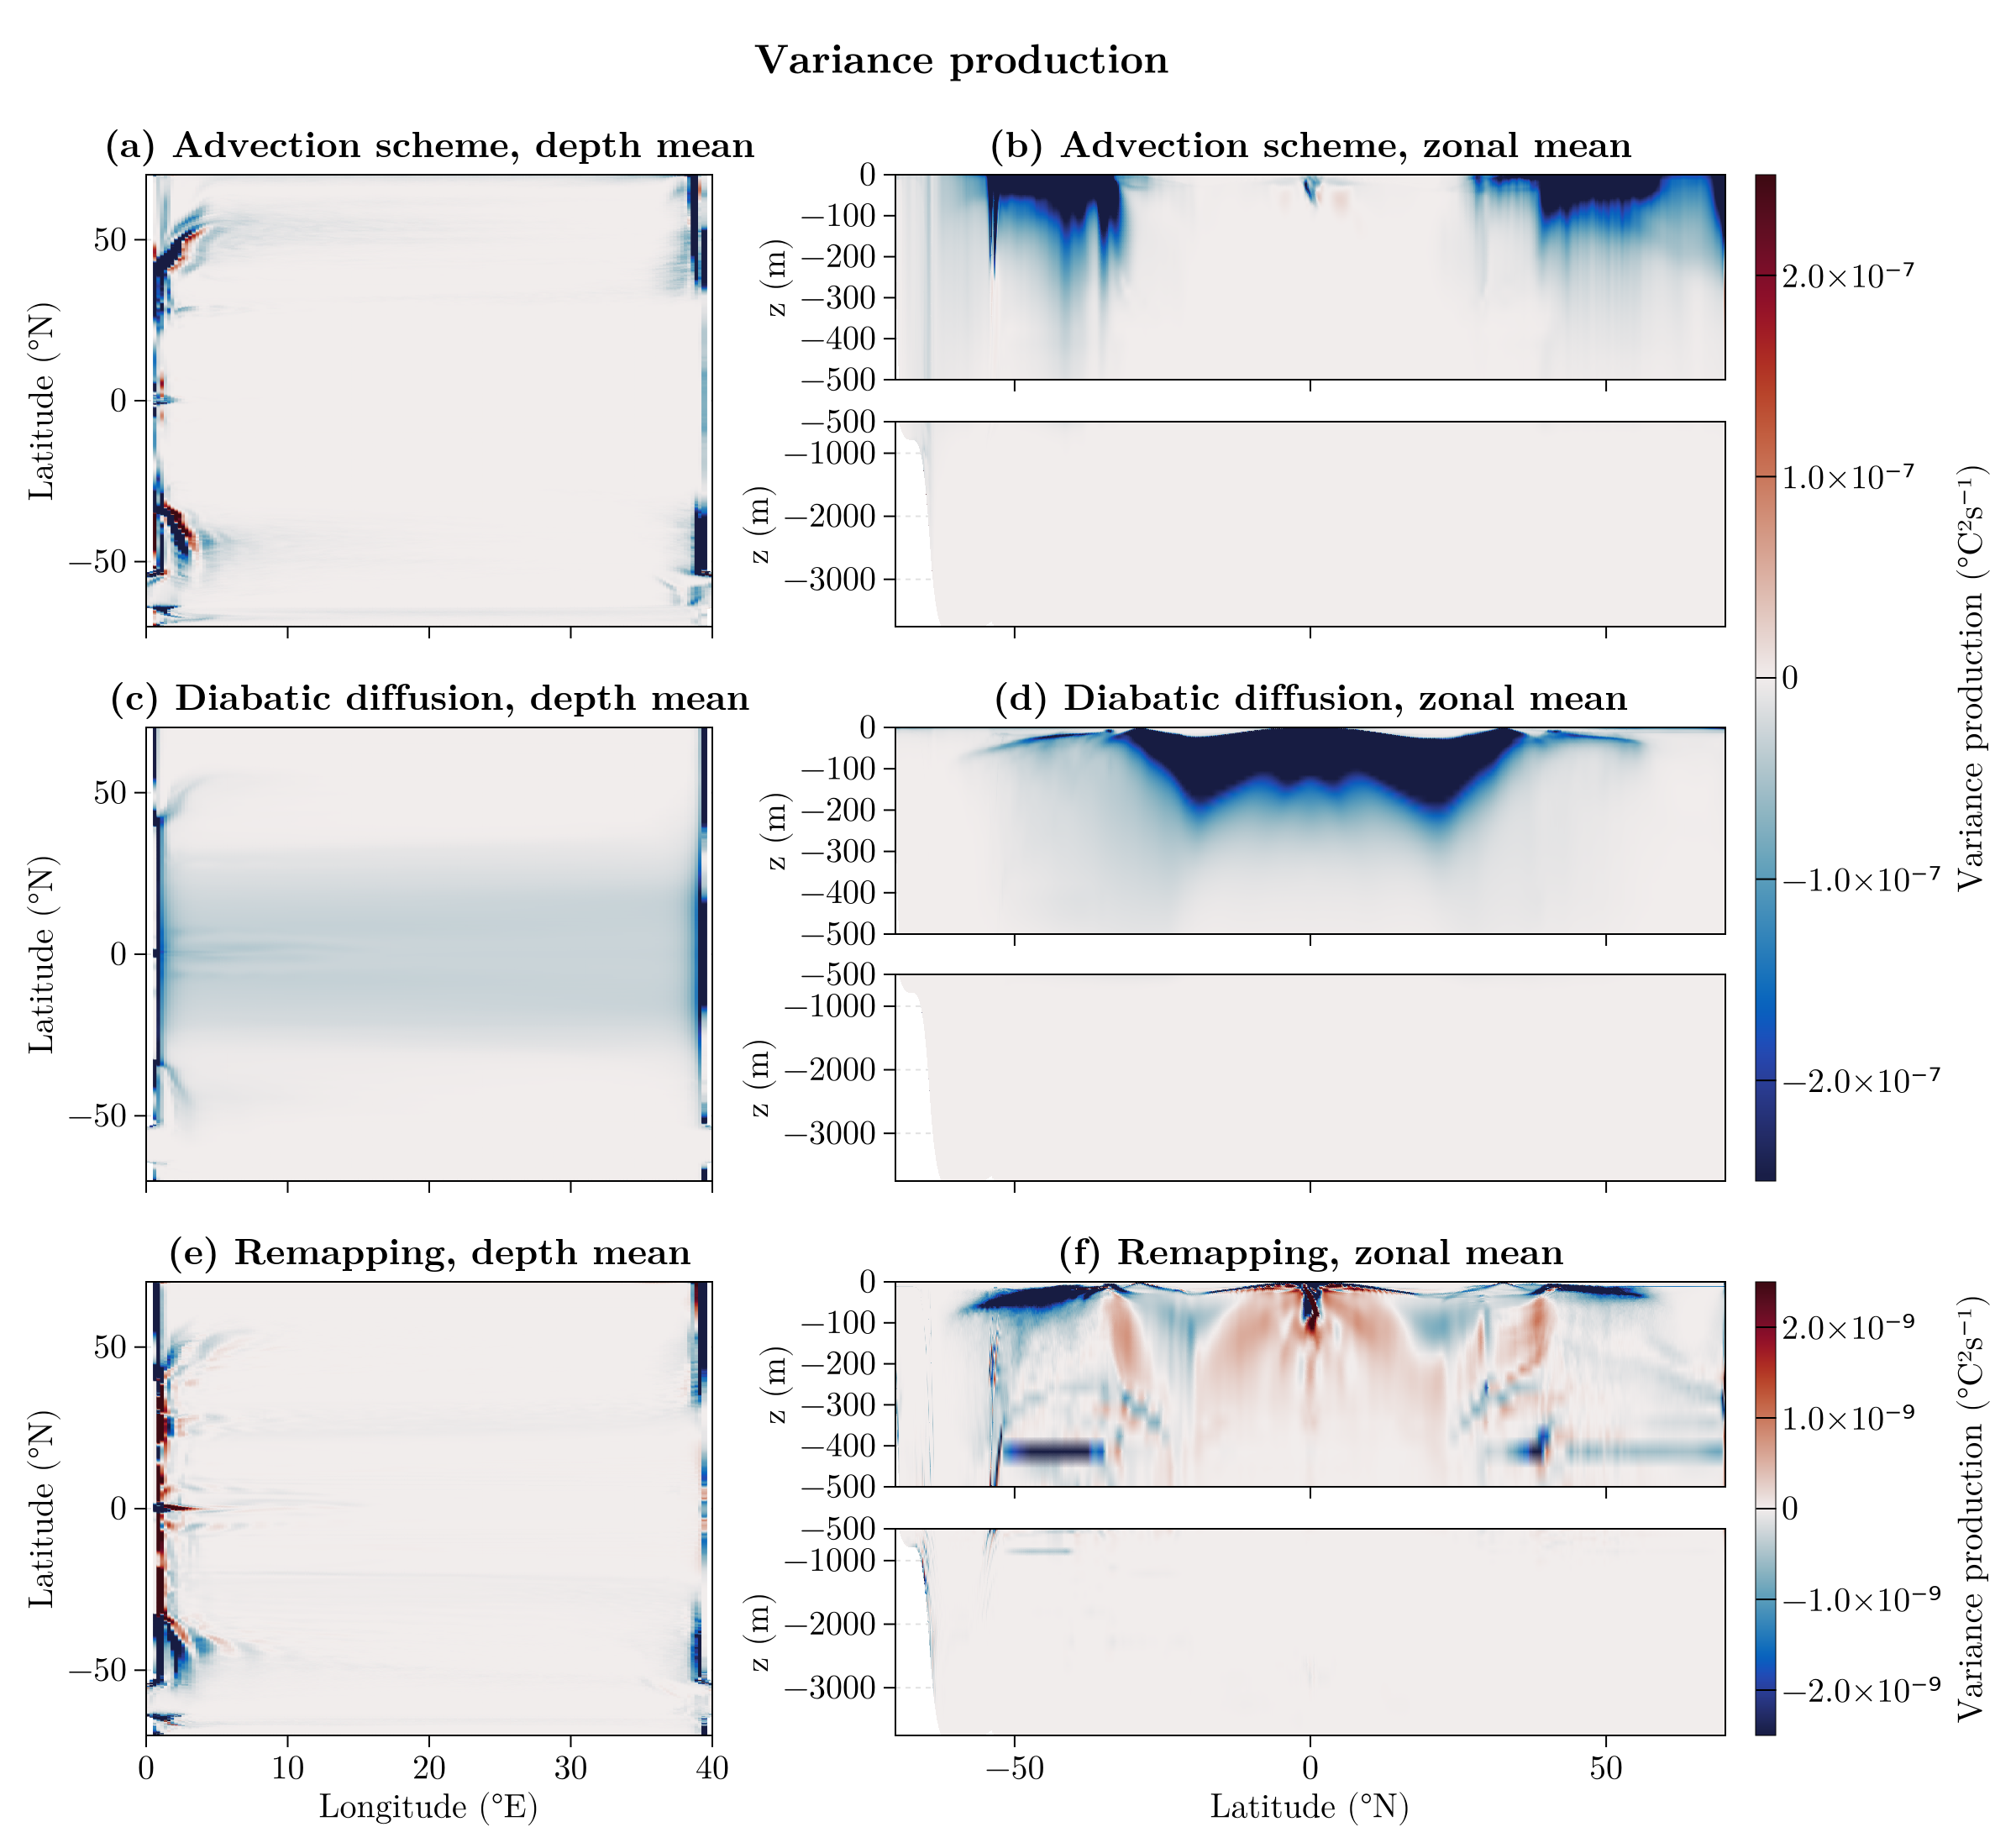

In [4]:
fig = Figure(size = (1200, 1100))

colorrange = (-2.5e-7, 2.5e-7)
colormap = :balance

# top = 1:50
# bot = top[end]+1:75

vp_diags = ["asvp", "diabatic", "remap"]
vl_labels = ["Advection scheme", "Diabatic diffusion", "Remapping"]
depth_labels = ["(a)", "(c)", "(e)"]
zonal_labels = ["(b)", "(d)", "(f)"]
   
output_grid = vp["output_grid"]
if output_grid == "monthlyz"

    for (i, v) ∈ enumerate(vp_diags)
        gl = fig[i, 1] = GridLayout()
        ax = Axis(gl[1, 1], xlabel = "Longitude (°E)", ylabel = "Latitude (°N)", title = depth_labels[i]*" $(vl_labels[i]), depth mean")
        hm = heatmap!(ax, vp["crs"].lonh, vp["crs"].lath, vp[v*"_depth_mean"]; colorrange, colormap)
        i < length(vp_diags) ? hidexdecorations!(ax, ticks = false) : nothing
        # top
        gr = fig[i, 2] = GridLayout()
        axtop = Axis(gr[1, 1], xlabel = "Latitude (°N)", ylabel = "z (m)", title = zonal_labels[i]*" $(vl_labels[i]), zonal mean" )
        hm = heatmap!(axtop, vp["crs"].lath, vp["zl"], vp[v*"_zonal_mean"]; colorrange, colormap)
        ylims!(axtop, -500, 0)
        hidexdecorations!(axtop, ticks = false)
        # bottom
        axbot = Axis(gr[2, 2], xlabel = "Latitude (°N)", ylabel = "z (m)")
        hm = heatmap!(axbot, vp["crs"].lath, vp["zl"], vp[v*"_zonal_mean"]; colorrange, colormap)
        ylims!(axbot, -4000, -500)
        axbot_zs.yticks = [-4000, -3000, -2000, -1000, -500]
    end

elseif output_grid == "monthly"

    for (i, v) ∈ enumerate(vp_diags)
        
        colorrange = i < length(vp_diags) ? (-2.5e-7, 2.5e-7) : (-2.5e-9, 2.5e-9)
        
        gl = fig[i, 1] = GridLayout()
        ax = Axis(gl[1, 1], xlabel = "Longitude (°E)", ylabel = "Latitude (°N)", title = depth_labels[i]*" $(vl_labels[i]), depth mean")
        hm = heatmap!(ax, vp["crs"].lonh, vp["crs"].lath, vp[v*"_depth_mean"]; colorrange, colormap)
        i < length(vp_diags) ? hidexdecorations!(ax, ticks = false) : nothing
        
        gr = fig[i, 2] = GridLayout()
        #  top
        axtop = Axis(gr[1, 1], xlabel = "Latitude (°N)", ylabel = "z (m)", title = zonal_labels[i]*" $(vl_labels[i]), zonal mean")
        hm = surface!(axtop, vp["crs"].lath, -vp["∫h"], zeros(size(vp[v*"_zonal_mean"])); 
                        color = vp[v*"_zonal_mean"], colorrange, colormap, shading = NoShading)
        xlims!(axtop, -70.15, 70.15)
        ylims!(axtop, -500, 0)
        hidexdecorations!(axtop, ticks = false)
        # bottom
        axbot = Axis(gr[2, 1], xlabel = "Latitude (°N)", ylabel = "z (m)")
        hm = surface!(axbot, vp["crs"].lath, -vp["∫h"], zeros(size(vp[v*"_zonal_mean"])); 
                        color = vp[v*"_zonal_mean"], colorrange, colormap, shading = NoShading)
        xlims!(axbot, -70.15, 70.15)
        ylims!(axbot, -3750, -500)
        i < length(vp_diags) ? hidexdecorations!(axbot, ticks = false) : nothing
        axbot.yticks = [-3000, -2000, -1000, -500]
        
        colgap!(gl, 10)
        colgap!(gr, 10)
        
        # # single cbar with same scale along the bottom horizontally
        # if i == length(vp_diags)
        #     Colorbar(fig[length(vp_diags)+1, :], hm, label = "Variance production (°C²s⁻¹)", vertical = false, flipaxis = false)
        # end
        # if using different cbar scale
        if i == length(vp_diags)-1
            Colorbar(fig[1:length(vp_diags)-1, 3], hm, label = "Variance production (°C²s⁻¹)")
        end
        if i == length(vp_diags)
            Colorbar(fig[length(vp_diags), 3], hm, label = "Variance production (°C²s⁻¹)")
        end
    end
end

Label(fig[0, :], "Variance production", fontsize = 24, font = :bold)
colsize!(fig.layout, 1, Relative(1/2.5))

fig

In [19]:
save("FiguresPaper1/zstar_20yr_var_prod.png", fig)

## Variance budget

Global mean time series of terms contributing to varinace change and a variance budget.

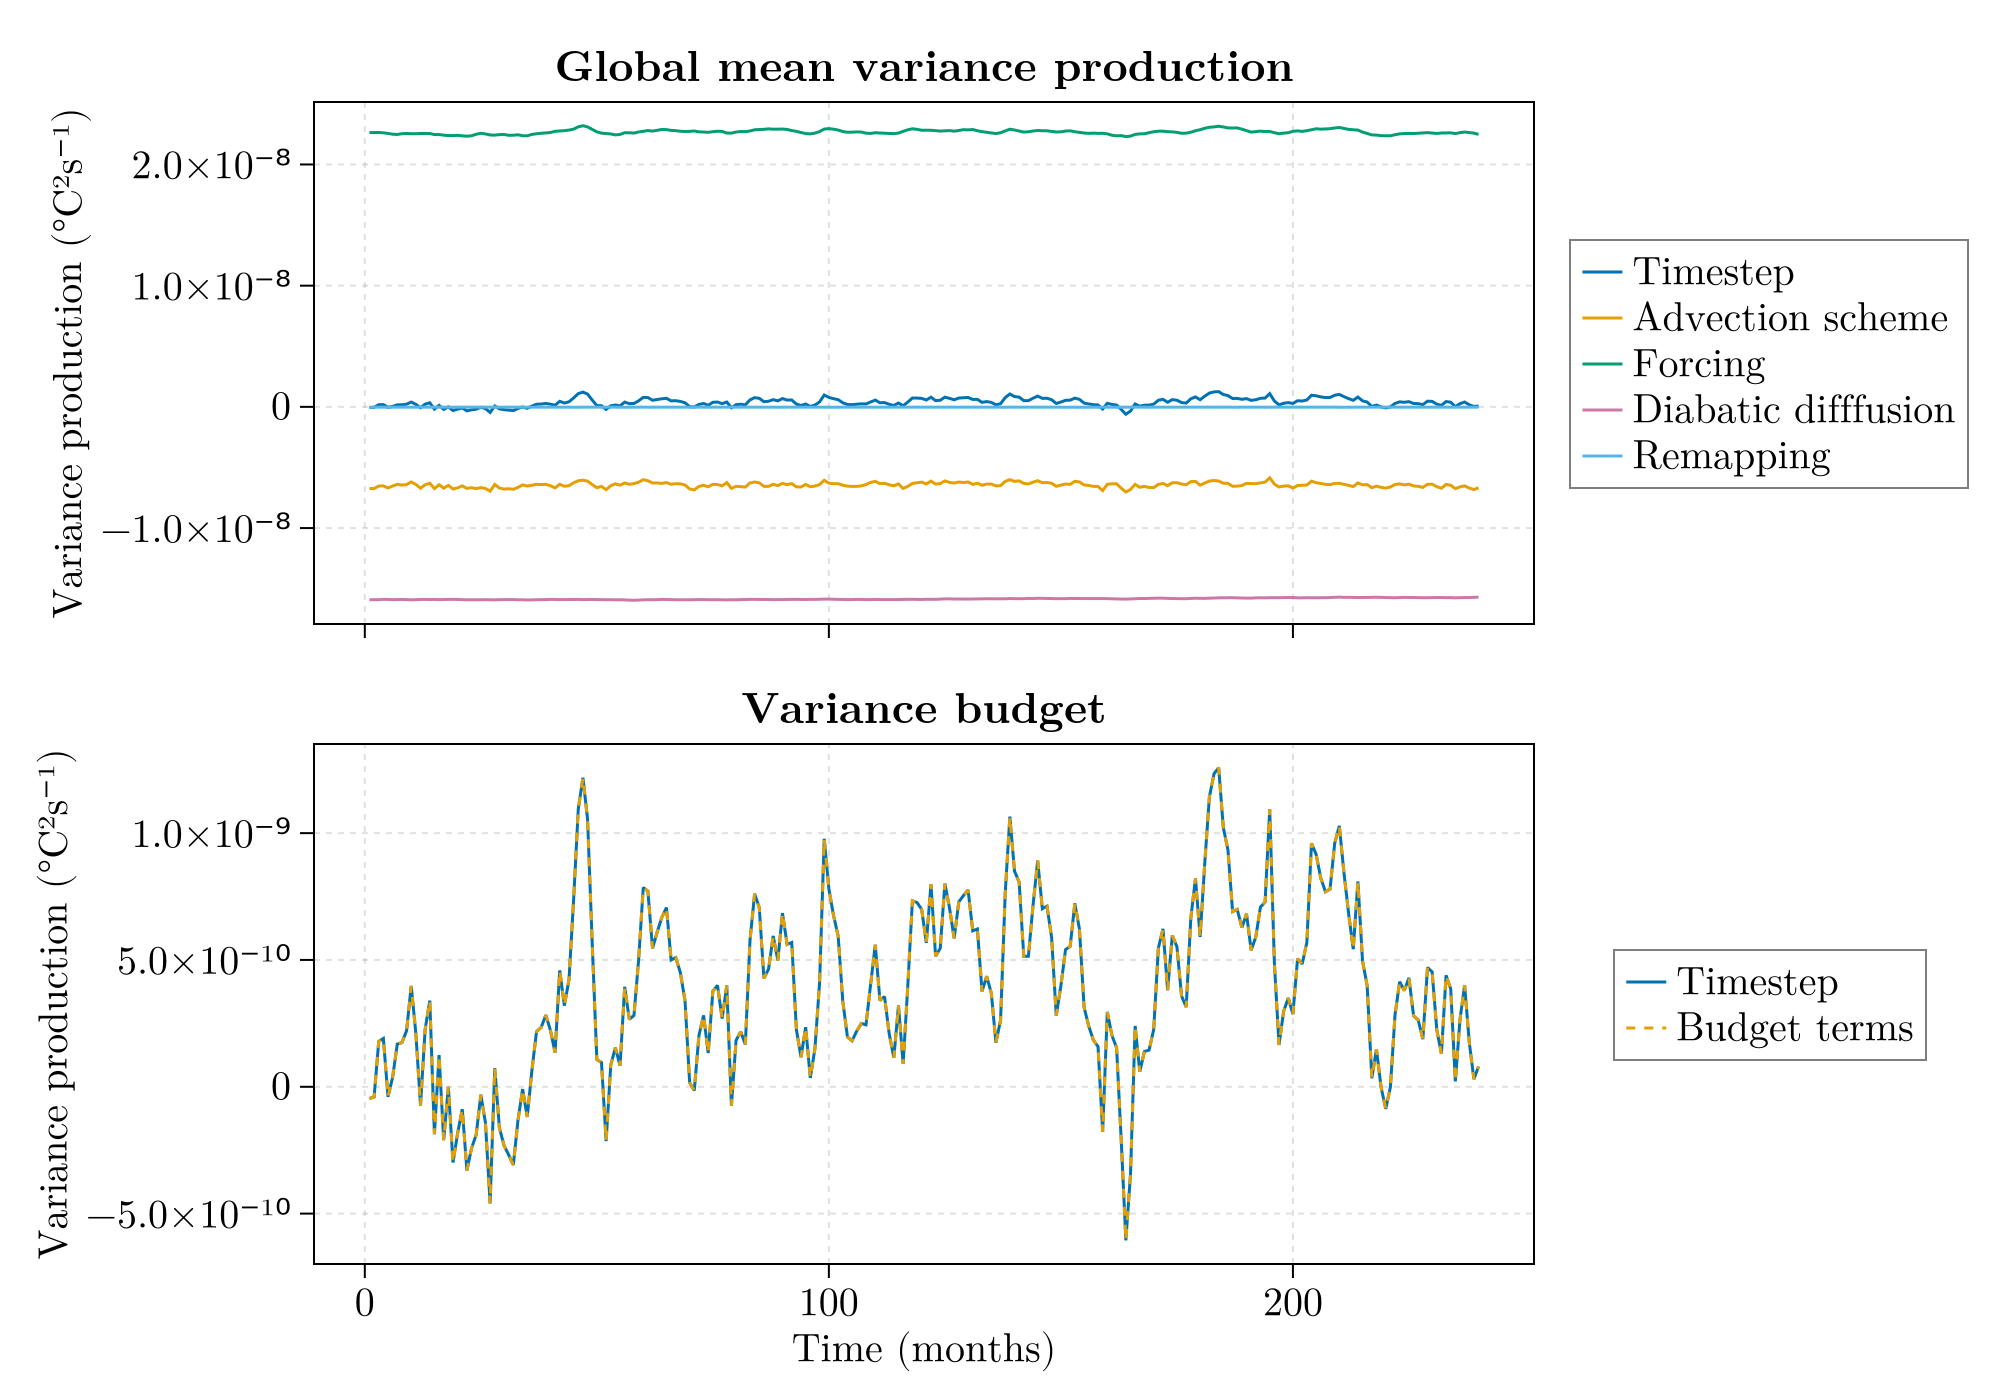

In [24]:
fig = Figure(size = (1000, 700))
budget_terms = ["T_tot_step_var_global", "asvp_global", "T_forc_vp_global", "diabatic_global", "remap_global"]
budget_labels = ["Timestep", "Advection scheme", "Forcing", "Diabatic difffusion", "Remapping"]
ax1 = Axis(fig[1, 1], xlabel = "Time (months)", ylabel = "Variance production (°C²s⁻¹)", title = "Global mean variance production")
hidexdecorations!(ax1, grid = false, ticks = false)
for (i, b) ∈ enumerate(budget_terms)
   lines!(ax1, vp[b][:], label = budget_labels[i])
end
Legend(fig[1, 2], ax1)
ax2 = Axis(fig[2, 1], xlabel = "Time (months)", ylabel = "Variance production (°C²s⁻¹)", title = "Variance budget")
variance_budget = vp["asvp_global"] .+ vp["T_forc_vp_global"] .+ vp["diabatic_global"] .+ vp["remap_global"]
lines!(ax2, vp["T_tot_step_var_global"][:], label = "Timestep")
lines!(ax2, variance_budget, linestyle = :dash, label = "Budget terms")
Legend(fig[2, 2], ax2)
fig

In [25]:
save("FiguresPaper1/zstar_20yr_variance_budget.png", fig)

## Over the slope

Likely will shift this analysis to the second study.

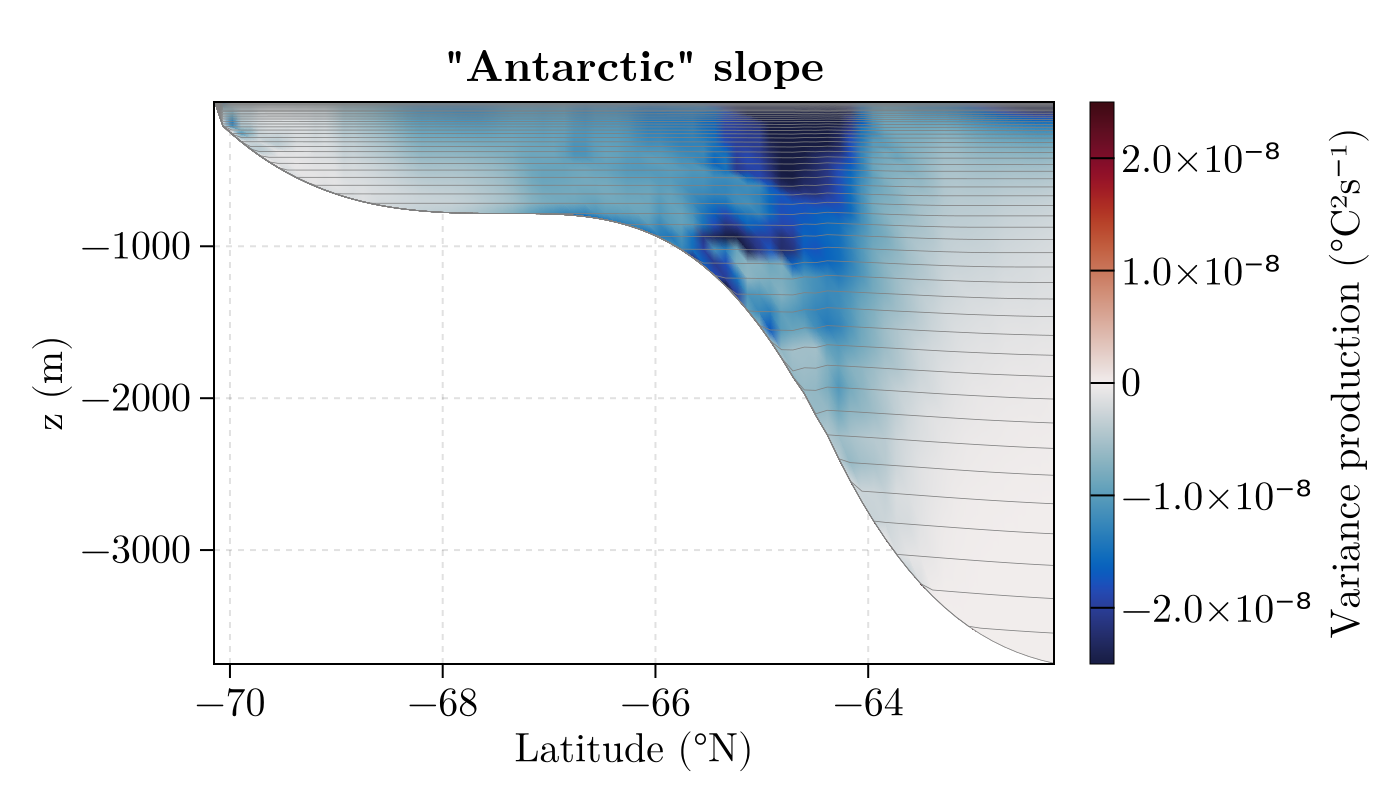

In [15]:
fig = Figure(size = (700, 400))

colorrange = (-2.5e-8, 2.5e-8)
colormap = :balance

lat_extent = 1:80

top = 1:50
bot = top[end]+1:75
   
output_grid = vp["output_grid"]
if output_grid == "monthlyz"

    # top
    ax = Axis(fig[1, 1], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "Zonal mean variance production" )
    hm = heatmap!(ax, vp["crs"].lath[lat_extent], vp["zl"], vp["zm_vd"][lat_extent, :]; colorrange, colormap)
    xlims!(ax, -70.15, vp["crs"].lath[lat_extent[end]])
    ylims!(ax, -3420, -200)
    Colorbar(fig[1, 2], hm, label = "Variance production (°C²s⁻¹)")

elseif output_grid == "monthly"

    ax = Axis(fig[1, 1], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "\"Antarctic\" slope")
    hm = surface!(ax, vp["crs"].lath[lat_extent], -vp["∫h"], zeros(size(vp["zm_vd"][lat_extent, :])); 
                    color = vp["zm_vd"][lat_extent, :], colorrange, colormap, shading = NoShading)
    for i ∈ 1:75 # layer heights
        lines!(ax, vp["crs"].lath[lat_extent], -vp["∫h"][lat_extent, i], color = :grey, linewidth = 0.4)
    end
    xlims!(ax, -70.15, vp["crs"].lath[lat_extent[end]])
    ylims!(ax, -3750, -50)
    Colorbar(fig[1, 2], hm, label = "Variance production (°C²s⁻¹)")
end
fig

In [16]:
save("FiguresPaper1/zstar_55yr_slope.png", fig)

In [17]:
pwd()

"/g/data/e14/jb2381/anu-tub/outputs"